# CDLD-LoS — Length-of-stay prediction using physician latent traits

This notebook reproduces **every table in the paper in a single run**. The
manuscript builder reads the CSVs written here, so re-running this notebook and
then re-running the builder keeps the paper's numbers consistent by construction.

MIMIC-IV records the admitting physician only as a de-identified identifier —
there are no observed physician attributes. We discover a latent representation
of each physician from interaction records alone (cyclic dual latent discovery,
CDLD) and combine it with 54 admission-time patient features.

## Getting the data

You do **not** need all of MIMIC-IV. Only **four files from the `hosp` module**
need to be placed in `MIMIC_DIR`.

| File | Used for |
|---|---|
| `admissions.csv.gz` | admit/discharge times, admission type and route, demographics, `admit_provider_id` |
| `patients.csv.gz` | sex, age |
| `omr.csv.gz` | blood pressure, body measurements |
| `microbiologyevents.csv.gz` | (reserved — not used by the current feature set) |

MIMIC-IV requires PhysioNet credentialing and a signed data use agreement.
**The raw data and any derived cache must not be redistributed**, so this
repository contains code only.

## Outputs

| CSV | Paper |
|---|---|
| `p_table2.csv` | Table 2 — how physician information is encoded |
| `p_table3.csv` | Table 3 — overall performance of the proposed model |
| `p_table4.csv` | Table 4 — four variants of the same architecture |
| `p_table5.csv` | Table 5 — when latent traits are discovered |
| `p_table6.csv` | Table 6 — subgroup error |
| `p_tableA1.csv` | Appendix A1 — four learners |
| `p_tableS1.csv` | Supplement S1 — all conditions |
| `p_tests.csv` / `p_aux.csv` | significance tests / auxiliary measurements |

## Running

A full run takes roughly 2–4 hours on one GPU (RTX 4090). To run in pieces,
enable `RUN_MAIN` → `RUN_BASELINE` → `RUN_DIAG` → `RUN_FAIRNESS` in that order;
the last three read latent traits and splits saved by the first.
`QUICK = True` runs fold 0 only and is for pipeline checking, not for the paper.

The `[검정 전용]` (tests only), `[요약 전용]` (summary only) and `[그림 전용]`
(figures only) cells read saved CSVs. After a kernel restart, running just the
Setup, constants and progress cells is enough to regenerate them — no retraining.

---

# CDLD-LoS — 의사 잠재특성을 이용한 재원일수 예측

「의사 잠재특성을 이용한 재원일수 예측」의 **모든 표를 한 번의 실행으로** 만든다.
원고 빌더가 여기서 나온 CSV를 읽어 표를 채우므로, 재실행 후 빌더를 다시 돌리면
원고의 수치가 자동으로 일치한다.

MIMIC-IV에서 입원 담당 의사는 비식별 식별자로만 존재하고 관측 특성이 없다.
상호작용 기록만으로 의사의 잠재특성을 발견하고(CDLD) 입원 시점 환자 특성 54차원과
결합한다.

**데이터 준비** — MIMIC-IV 전체를 받을 필요가 없다. `hosp` 모듈의 4개 파일만
`MIMIC_DIR`에 두면 된다(위 표). PhysioNet 자격과 데이터 사용 동의가 필요하며
**원자료와 파생 캐시는 재배포할 수 없다.**

**실행** — GPU 기준 약 2~4시간. 나눠 돌리려면 `RUN_MAIN` → `RUN_BASELINE` →
`RUN_DIAG` → `RUN_FAIRNESS` 순서를 지킨다(뒤 셋은 앞이 저장한 잠재특성·분할을 읽는다).
`QUICK = True`는 fold 0만 도는 점검용이며 논문 수치가 아니다.
`[검정 전용]`·`[요약 전용]`·`[그림 전용]` 셀은 저장된 CSV만 읽으므로, 커널 재시작 후
Setup·상수·progress 3개 셀만 실행하면 재생성된다.

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os, gc, json, pickle, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
for _g in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(_g, True)   # 필요한 만큼만 할당
from tensorflow.keras.layers import (
    Input, Dense, concatenate, Dropout, BatchNormalization,
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras import layers, utils, regularizers, constraints, initializers
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             r2_score, roc_auc_score)
from scipy import stats

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
print("TensorFlow", tf.__version__)

2026-07-31 01:21:04.741465: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785460864.754451  322664 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785460864.758481  322664 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1785460864.768311  322664 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785460864.768322  322664 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785460864.768323  322664 computation_placer.cc:177] computation placer alr

TensorFlow 2.19.0


In [2]:
from sklearn.model_selection import KFold

# ---------------- paths / constants ----------------
MIMIC_DIR = Path("/workspace/mimic_data")
ROOT = Path.cwd()
CACHE_DIR = ROOT / "cache";    CACHE_DIR.mkdir(exist_ok=True)
FIGURE_DIR = ROOT / "figures"; FIGURE_DIR.mkdir(exist_ok=True)
TABLE_DIR = ROOT / "tables";   TABLE_DIR.mkdir(exist_ok=True)
ART_DIR = ROOT / "artifacts";  ART_DIR.mkdir(exist_ok=True)

# CDLD hyperparameters — 선행 CDLD 연구의 값을 그대로 사용하며 본 데이터에 맞춰
# 조정하지 않았다. 별도의 탐색 결과는 보충자료 S2 참조.
LATENT_SIZE = 64
CYCLES = 15
SUB_EPOCH = 2
CYCLE_PATIENCE = 3
BATCH_SIZE = 512
initial_learning_rate = 0.0005
PREDICTOR_EPOCH = 300
PREDICTOR_PATIENCE = 20

N_FOLDS = 5
SEED = 42

LOS_MIN_H, LOS_MAX_D = 2, 28
SHORT_MAX_D = 5

# 연장 재원(prolonged LoS) 이진 지표의 절단값. 선행 관행에 따라 각 fold **학습
# 분할의 75분위**로 사전 고정한다(결과를 보고 고르지 않기 위해). 연속 예측값을
# 점수로 그대로 사용하며 별도의 분류기 학습은 없다.
PLOS_PERCENTILE = 75

# ---- 실행 블록 (나눠 돌릴 때 사용) ----
RUN_MAIN = True        # 실험 1: 조건별 성능 (표 2·3·4, 보충 S1)  — 가장 오래 걸림
RUN_BASELINE = True    # 실험 2: 학습기 4종 (부록 A1)
RUN_DIAG = True        # 실험 3: 셔플·층화·SHAP (표 5)
RUN_FAIRNESS = True    # 실험 4: 공정성 (표 6)

QUICK = False          # True면 fold 0만 — 파이프라인 점검용. 논문 수치 아님

PAPER_DPI = 300
def save_fig(fig, name):
    fig.savefig(FIGURE_DIR / f"{name}.png", dpi=PAPER_DPI, bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{name}.pdf", bbox_inches="tight")

MAIN_CSV = TABLE_DIR / "p_main.csv"
AUX_CSV = TABLE_DIR / "p_aux.csv"
BASE_CSV = TABLE_DIR / "p_baseline.csv"

print(f"N_FOLDS={N_FOLDS}  LATENT_SIZE={LATENT_SIZE}  "
      f"PLOS cut = train {PLOS_PERCENTILE}th pct" + ("   [QUICK]" if QUICK else ""))

N_FOLDS=5  LATENT_SIZE=64  PLOS cut = train 75th pct


In [3]:
# ---------------- progress 유틸 ----------------
# 장시간 셀의 침묵 구간을 만들지 않는다.
class EpochProgress(tf.keras.callbacks.Callback):
    def __init__(self, tag, every=25):
        super().__init__(); self.tag, self.every = tag, every; self.t0 = None
    def on_train_begin(self, logs=None):
        self.t0 = time.time()
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every == 0:
            print(f"        {self.tag} epoch {epoch+1:3d} "
                  f"val_loss {logs.get('val_loss', float('nan')):.5f} "
                  f"[{time.time()-self.t0:.0f}s]", flush=True)

def hms(sec):
    sec = int(sec)
    return (f"{sec//3600}h{(sec%3600)//60:02d}m{sec%60:02d}s" if sec >= 3600
            else f"{sec//60}m{sec%60:02d}s")

def fold_splits(y_len, n_folds, seed):
    """입원 단위 무작위 K-fold. 학습 분할의 뒤 10%를 검증으로 뗀다.
    동일 환자·의사가 학습과 평가에 공존할 수 있는 transductive 설정이다."""
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    for fold, (tr, te) in enumerate(kf.split(np.arange(y_len))):
        cut = int(len(tr) * 0.9)
        yield fold, tr[:cut], tr[cut:], te

## Data and features / 데이터와 특성

In [4]:
# ---------------- load & filter admissions (v1 캐시 재사용) ----------------
CACHE = CACHE_DIR / "los_admissions.parquet"

if CACHE.exists():
    adm = pd.read_parquet(CACHE)
    print(f"cache hit: {len(adm):,} admissions")
else:
    adm = pd.read_csv(MIMIC_DIR / "admissions.csv.gz",
                      parse_dates=["admittime", "dischtime", "deathtime",
                                   "edregtime", "edouttime"])
    n0 = len(adm)
    adm["los_days"] = (adm["dischtime"] - adm["admittime"]).dt.total_seconds() / 86400.0
    adm = adm[adm["deathtime"].isna()]
    adm = adm[~adm["admission_type"].str.contains("OBSERVATION", na=False)]
    adm = adm.dropna(subset=["subject_id", "hadm_id", "admit_provider_id"])
    adm = adm[(adm["los_days"] >= LOS_MIN_H / 24.0) & (adm["los_days"] <= LOS_MAX_D)]
    print(f"filtered: {n0:,} -> {len(adm):,} ({len(adm)/n0:.1%})")
    adm.to_parquet(CACHE)

adm = adm.sort_values(["subject_id", "admittime"]).reset_index(drop=True)
print(f"patients: {adm.subject_id.nunique():,} | "
      f"physicians: {adm.admit_provider_id.nunique():,}")

cache hit: 294,701 admissions
patients: 148,239 | physicians: 1,807


In [5]:
# ---------------- patient features v2 (입원 시점 정보만) ----------------
# v1(인구학+OMR, 33차원, R^2 0.02)의 신호 부족을 해결하기 위한 강화:
#  + admission_type / admission_location 원핫
#  + 응급 경유 여부와 ED 체류시간
#  + 입원 시각(주말, 야간) — 운영 신호
#  + 과거력: 이전 입원 횟수, 직전까지의 평균 LoS (시간순 shift — 입원 시점에
#    알 수 있는 정보만 사용, 누수 없음을 명시)
# 주의: diagnoses_icd는 퇴원 시 코딩이므로 사용하지 않는다 (누수).
PF_CACHE = CACHE_DIR / "patient_features_v2.parquet"

if PF_CACHE.exists():
    pat_feat = pd.read_parquet(PF_CACHE)
    print(f"cache hit: {pat_feat.shape}")
else:
    patients = pd.read_csv(MIMIC_DIR / "patients.csv.gz")
    base = adm.merge(patients[["subject_id", "gender", "anchor_age"]],
                     on="subject_id", how="left")

    def group_rare(s, top=7):
        keep = s.value_counts().head(top).index
        return s.where(s.isin(keep), "OTHER").fillna("UNKNOWN")

    cats = pd.DataFrame({
        "insurance": base["insurance"].fillna("UNKNOWN"),
        "language": group_rare(base["language"]),
        "marital_status": base["marital_status"].fillna("UNKNOWN"),
        "race": group_rare(base["race"]),
        "admission_type": base["admission_type"].fillna("UNKNOWN"),
        "admission_location": group_rare(base["admission_location"], top=8),
    })
    onehot = pd.get_dummies(cats, dtype=np.float32)

    at = pd.to_datetime(base["admittime"])
    ed = pd.to_datetime(base["edregtime"], errors="coerce")
    ed_hours = ((at - ed).dt.total_seconds() / 3600.0).clip(0, 48)
    num = pd.DataFrame({
        "gender": (base["gender"] == "M").astype(np.float32),
        "anchor_age": base["anchor_age"].astype(np.float32),
        "via_ed": ed.notna().astype(np.float32),
        "ed_hours": ed_hours.fillna(0).astype(np.float32) / 48.0,
        "weekend": at.dt.dayofweek.isin([5, 6]).astype(np.float32),
        "night": ((at.dt.hour >= 20) | (at.dt.hour < 7)).astype(np.float32),
    })
    num["anchor_age"] = (num["anchor_age"] - num["anchor_age"].min()) / (
        num["anchor_age"].max() - num["anchor_age"].min())

    # 과거력 (시간순 정렬 상태에서 subject별 shift — 현재 입원 정보는 미포함)
    g = base.groupby("subject_id")
    num["prior_n"] = (g.cumcount().astype(np.float32) / 10.0).clip(0, 1)
    prior_mean = (g["los_days"].transform(
        lambda s: s.shift(1).expanding().mean()))
    num["prior_mean_los"] = (np.log1p(prior_mean.fillna(prior_mean.median()))
                             .astype(np.float32) / np.log1p(LOS_MAX_D))
    num["has_history"] = prior_mean.notna().astype(np.float32)

    omr_path = MIMIC_DIR / "omr.csv.gz"
    if omr_path.exists():
        omr = pd.read_csv(omr_path)
        omr = omr[omr["result_name"].str.contains(
            "Blood Pressure|BMI|Height|Weight", na=False)]
        bp = omr[omr["result_name"].str.contains("Blood Pressure")].copy()
        sp = bp["result_value"].str.split("/", expand=True)
        bp["sys"] = pd.to_numeric(sp[0], errors="coerce")
        bp["dia"] = pd.to_numeric(sp[1], errors="coerce")
        bp_agg = bp.groupby("subject_id")[["sys", "dia"]].mean()
        body = omr[~omr["result_name"].str.contains("Blood Pressure")].copy()
        body["val"] = pd.to_numeric(body["result_value"], errors="coerce")
        body["kind"] = np.select(
            [body["result_name"].str.contains("BMI"),
             body["result_name"].str.contains("Height"),
             body["result_name"].str.contains("Weight")],
            ["bmi", "height", "weight"], default="other")
        body_agg = body[body.kind != "other"].pivot_table(
            index="subject_id", columns="kind", values="val", aggfunc="mean")
        m = body_agg
        m["bmi"] = m["bmi"].fillna(m["weight"] * 703 / (m["height"] ** 2))
        m["weight"] = m["weight"].fillna(m["bmi"] * (m["height"] ** 2) / 703)
        m["height"] = m["height"].fillna(np.sqrt(m["weight"] * 703 / m["bmi"]))
        extra = bp_agg.join(body_agg, how="outer")
        for c in extra.columns:
            v = extra[c]
            z = (v - v.mean()) / (v.std() + 1e-9)
            v = v.mask(z.abs() > 3)
            extra[c] = (v - v.min()) / (v.max() - v.min() + 1e-9)
        extra = extra.reset_index()
        num = pd.concat([base[["subject_id"]].reset_index(drop=True),
                         num.reset_index(drop=True)], axis=1)
        num = num.merge(extra, on="subject_id", how="left").drop(columns=["subject_id"])

    pat_feat = pd.concat([onehot.reset_index(drop=True),
                          num.reset_index(drop=True)], axis=1).astype(np.float32)
    pat_feat = pat_feat.fillna(pat_feat.median(numeric_only=True))
    pat_feat.to_parquet(PF_CACHE)

FEATURE_DIM = pat_feat.shape[1]
print(f"patient feature matrix v2: {pat_feat.shape}")

cache hit: (294701, 54)
patient feature matrix v2: (294701, 54)


In [6]:
# ---------------- entity 인덱싱과 타깃 ----------------
patients_u = np.sort(adm["subject_id"].unique())
providers_u = np.sort(adm["admit_provider_id"].unique())
user_index = {s: i for i, s in enumerate(patients_u)}
item_index = {p: i for i, p in enumerate(providers_u)}

u = adm["subject_id"].map(user_index).to_numpy(np.int32)
q = adm["admit_provider_id"].map(item_index).to_numpy(np.int32)
los_days = adm["los_days"].to_numpy(np.float32)
y = np.log1p(los_days).astype(np.float32)

N_PATIENTS, N_PHYSICIANS = len(patients_u), len(providers_u)
patient_features = pat_feat.to_numpy(np.float32)
is_short = los_days <= SHORT_MAX_D

print(f"patients {N_PATIENTS:,} | physicians {N_PHYSICIANS:,} | "
      f"admissions {len(y):,}")

def to_days(p): return np.expm1(p)

def rmse_days(y_log, p_log):
    return float(np.sqrt(mean_squared_error(
        np.expm1(y_log), np.clip(np.expm1(p_log), 0, None))))

def report_days(y_log, p_log, label):
    t, p = np.expm1(y_log), np.clip(np.expm1(p_log), 0, None)
    r = {"label": label,
         "rmse_days": float(np.sqrt(mean_squared_error(t, p))),
         "mae_days": float(mean_absolute_error(t, p)),
         "r2": float(r2_score(t, p))}
    print(f"{label:24s} RMSE {r['rmse_days']:6.3f} d | "
          f"MAE {r['mae_days']:6.3f} d | R^2 {r['r2']:6.3f}")
    return r

patients 148,239 | physicians 1,807 | admissions 294,701


## Model / 모델

In [7]:
# ---------------- CDLD 구성요소 ----------------
# Finder 2개가 환자·의사 잠재특성 테이블을 공유하며 교대 학습한다
# (cyclic dual latent discovery). Predictor는 비대칭 설계 —
# 환자는 관측 특성 54차원, 의사는 잠재특성만 사용한다.
class ValueOfIndexLayer(layers.Layer):
    def __init__(self, index, **kw):
        super().__init__(**kw); self.index = index
    def call(self, x):
        return tf.cast(x[:, self.index], tf.int32)

class IndexedValueLayer(layers.Layer):
    def __init__(self, value_shape, trainable=True, **kw):
        super().__init__(**kw)
        self.value_shape = value_shape; self._trainable_flag = trainable
    def build(self, _):
        self.values = self.add_weight(
            shape=self.value_shape, initializer="random_uniform",
            trainable=self._trainable_flag, name="values")
    def call(self, idx):
        return tf.gather(self.values, idx)
    def set_value(self, v): self.values.assign(v)
    def get_value(self): return self.values.numpy()

def dense_block(x, units, drop):
    x = Dense(units, activation="swish", use_bias=True,
              kernel_regularizer=l2(0.0001))(x)
    x = BatchNormalization()(x)
    return Dropout(drop)(x)

def build_finder(user_shape, feat_dim, item_shape,
                 user_trainable=True, item_trainable=True):
    inp = Input((2,), name="index_input")
    ui = ValueOfIndexLayer(0)(inp); qi = ValueOfIndexLayer(1)(inp)
    UL = IndexedValueLayer(user_shape, trainable=user_trainable, name="user_latents")
    IL = IndexedValueLayer(item_shape, trainable=item_trainable, name="item_latents")
    feat_in = Input((feat_dim,), name="patient_feature_input")
    xu = dense_block(UL(ui), 96, 0.2)
    xf = dense_block(feat_in, 64, 0.2)
    xi = dense_block(IL(qi), 96, 0.2)
    x = concatenate([xu, xf, xi])
    x = BatchNormalization()(x)
    x = dense_block(x, 256, 0.3)
    x = dense_block(x, 128, 0.3)
    x = dense_block(x, 64, 0.2)
    out = Dense(1, activation="linear", kernel_regularizer=l2(0.0001))(x)
    m = Model([inp, feat_in], out)
    m.user_latents_layer = UL; m.item_latents_layer = IL
    return m

def build_variant(feat_dim, latent_dim, use_pf=True,
                  use_pat_lat=False, use_phy_lat=True):
    """제안 모델 = (use_pf=True, use_pat_lat=False, use_phy_lat=True)."""
    assert use_pf or use_pat_lat or use_phy_lat, "입력이 하나는 있어야 한다"
    ins, xs = [], []
    if use_pat_lat:
        a = Input((latent_dim,), name="patient_latent_input")
        ins.append(a); xs.append(dense_block(a, 96, 0.2))
    if use_pf:
        b = Input((feat_dim,), name="patient_feature_input")
        ins.append(b); xs.append(dense_block(b, 64, 0.2))
    if use_phy_lat:
        c = Input((latent_dim,), name="physician_latent_input")
        ins.append(c); xs.append(dense_block(c, 96, 0.2))
    x = concatenate(xs) if len(xs) > 1 else xs[0]
    x = BatchNormalization()(x)
    x = dense_block(x, 256, 0.3)
    x = dense_block(x, 128, 0.3)
    x = dense_block(x, 64, 0.2)
    return Model(ins, Dense(1, activation="linear",
                            kernel_regularizer=l2(0.0001))(x))

def variant_inputs(idx, UL, IL, use_pf=True, use_pat_lat=False,
                   use_phy_lat=True, extra=None):
    """extra: (전체 행, k) 스칼라 특성 배열 또는 None. 환자 특성 뒤에 붙인다."""
    out = []
    if use_pat_lat: out.append(UL[u[idx]])
    if use_pf:
        pf_ = patient_features[idx]
        if extra is not None:
            pf_ = np.hstack([pf_, extra[idx]])
        out.append(pf_)
    if use_phy_lat: out.append(IL[q[idx]])
    return out

def metrics_days(y_log, p_log, plos_cut=None, short_mask=None):
    """일 단위 회귀 지표. 절단값이 주어지면 연장 재원 AUROC를 병기한다.
    AUROC는 연속 예측값을 점수로 그대로 사용하며 추가 학습이 없다."""
    t, p = np.expm1(y_log), np.clip(np.expm1(p_log), 0, None)
    out = {"rmse_days": float(np.sqrt(mean_squared_error(t, p))),
           "mae_days": float(mean_absolute_error(t, p)),
           "r2": float(r2_score(t, p))}
    if short_mask is not None:
        for nm, m in [("short", short_mask), ("long", ~short_mask)]:
            if m.sum() > 1:
                out[f"rmse_{nm}"] = float(np.sqrt(mean_squared_error(t[m], p[m])))
                out[f"mae_{nm}"] = float(mean_absolute_error(t[m], p[m]))
    if plos_cut is not None:
        lab = (t > plos_cut).astype(int)
        out["plos_auroc"] = (float(roc_auc_score(lab, p))
                             if 0 < lab.sum() < len(lab) else float("nan"))
        out["plos_rate"] = float(lab.mean())
    return out

In [8]:
# ---------------- 학습 루틴 ----------------
def discover_latents(train_idx, valid_idx, tag=""):
    """Finder 이중 순환 + 사이클 단위 조기종료(best 사이클 복원).
    주의: finder의 ReduceLROnPlateau는 SUB_EPOCH(2)가 콜백 patience(2)와 같고
    Keras가 fit마다 콜백 상태를 초기화하므로 실질적으로 작동하지 않는다.
    즉 finder는 고정 학습률로 학습된다 — 사이클마다 실제 학습률을 출력해 확인한다."""
    tf.keras.backend.clear_session(); gc.collect()
    user_lat = np.random.random((N_PATIENTS, LATENT_SIZE)).astype(np.float32)
    item_lat = np.random.random((N_PHYSICIANS, LATENT_SIZE)).astype(np.float32)
    fx = np.stack([u, q], 1).astype(np.float32)

    uf = build_finder(user_lat.shape, FEATURE_DIM, item_lat.shape, True, False)
    itf = build_finder(user_lat.shape, FEATURE_DIM, item_lat.shape, False, True)
    for f in (uf, itf):
        f.user_latents_layer.set_value(user_lat)
        f.item_latents_layer.set_value(item_lat)
        f.compile(loss="mse", optimizer=Adam(initial_learning_rate),
                  metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")])
    rl = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5)
    tin = [fx[train_idx], patient_features[train_idx]]
    vin = [fx[valid_idx], patient_features[valid_idx]]

    best, best_UL, best_IL, wait, best_c = np.inf, None, None, 0, 0
    t0 = time.time()
    for c in range(CYCLES):
        uf.item_latents_layer.set_value(itf.item_latents_layer.get_value())
        uf.fit(tin, y[train_idx], epochs=SUB_EPOCH, batch_size=BATCH_SIZE,
               validation_data=(vin, y[valid_idx]), callbacks=[rl], verbose=0)
        itf.user_latents_layer.set_value(uf.user_latents_layer.get_value())
        h2 = itf.fit(tin, y[train_idx], epochs=SUB_EPOCH, batch_size=BATCH_SIZE,
                     validation_data=(vin, y[valid_idx]), callbacks=[rl], verbose=0)
        vl = float(h2.history["val_loss"][-1])
        marker = ""
        if vl < best - 1e-5:
            best, wait, best_c = vl, 0, c + 1
            best_UL = uf.user_latents_layer.get_value()
            best_IL = itf.item_latents_layer.get_value()
            marker = "  <- best"
        else:
            wait += 1
        try:
            lr_now = float(itf.optimizer.learning_rate.numpy())
        except Exception:
            lr_now = float("nan")
        print(f"    cycle {c+1:2d}/{CYCLES} val RMSE(log) {np.sqrt(vl):.4f} "
              f"lr {lr_now:.2e} [{time.time()-t0:.0f}s]{marker}", flush=True)
        if wait >= CYCLE_PATIENCE:
            print(f"    early stop at cycle {c+1} (best cycle {best_c} 복원)",
                  flush=True)
            break
    n_run = c + 1
    del uf, itf
    tf.keras.backend.clear_session(); gc.collect()
    return best_UL, best_IL, best_c, n_run, lr_now

def fit_predictor(train_idx, valid_idx, UL, IL, tag="",
                  use_pf=True, use_pat_lat=False, use_phy_lat=True, extra=None):
    fdim = FEATURE_DIM + (0 if extra is None else extra.shape[1])
    m = build_variant(fdim, LATENT_SIZE, use_pf, use_pat_lat, use_phy_lat)
    m.compile(loss="mse", optimizer=Adam(initial_learning_rate),
              metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")])
    m.fit(variant_inputs(train_idx, UL, IL, use_pf, use_pat_lat, use_phy_lat, extra),
          y[train_idx], epochs=PREDICTOR_EPOCH, batch_size=BATCH_SIZE,
          validation_data=(variant_inputs(valid_idx, UL, IL, use_pf,
                                          use_pat_lat, use_phy_lat, extra),
                           y[valid_idx]),
          callbacks=[EarlyStopping(monitor="val_loss",
                                   patience=PREDICTOR_PATIENCE,
                                   restore_best_weights=True),
                     ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                       patience=5, min_lr=1e-6),
                     EpochProgress(tag or "predictor")],
          verbose=0)
    return m

In [9]:
# ---------------- 학습 없는 집계 대조군 ----------------
# 의사별 과거 평균 재원일수: 모델 적합 없이, 학습 분할에 있는 그 의사의 실제
# 재원일수 평균을 그대로 예측값으로 쓴다. 학습 분할에 없는 의사는 전체 평균.
# 일(day) 공간에서 평균을 낸 뒤 로그로 되돌린다 — 로그 공간 평균을 쓰면
# Jensen 부등식으로 아래 편향되어 바닥값이 부당하게 나빠진다.
def pred_global_mean(tr_idx, te_idx):
    g = float(np.log1p(np.expm1(y[tr_idx]).mean()))
    return np.full(len(te_idx), g, np.float32)

def pred_physician_mean(tr_idx, te_idx):
    d = np.expm1(y[tr_idx]).astype(np.float64)
    g = float(d.mean())
    sm = np.bincount(q[tr_idx], weights=d, minlength=N_PHYSICIANS)
    n = np.bincount(q[tr_idx], minlength=N_PHYSICIANS)
    m = np.log1p(np.where(n > 0, sm / np.maximum(n, 1), g)).astype(np.float32)
    return m[q[te_idx]]

def make_phy_scalars(tr_idx):
    """의사 정보를 스칼라 한 컬럼으로 넣는 대안 설명 대조군을 만든다.
      phy_mean        : 의사별 과거 평균 재원일수
      phy_mean_shrunk : 경험적 베이즈 축소추정판 — 기록이 적은 의사일수록
                        전체 평균 쪽으로 당긴다. k = 의사내 분산 / 의사간 분산
      phy_count       : 의사의 진료량(log)
    전부 각 fold의 학습 분할에서만 계산한다(누수 방지)."""
    yt = y[tr_idx].astype(np.float64); g = float(yt.mean())
    n = np.bincount(q[tr_idx], minlength=N_PHYSICIANS).astype(np.float64)
    s1 = np.bincount(q[tr_idx], weights=yt, minlength=N_PHYSICIANS)
    s2 = np.bincount(q[tr_idx], weights=yt ** 2, minlength=N_PHYSICIANS)
    seen = n > 0
    mean_j = np.where(seen, s1 / np.maximum(n, 1), g)
    within_ss = np.clip(s2 - n * mean_j ** 2, 0, None)
    s2_within = float(within_ss.sum() / max(n.sum() - seen.sum(), 1.0))
    s2_between = max(float(np.var(mean_j[seen])
                           - s2_within * float(np.mean(1.0 / n[seen])))
                     if seen.sum() > 1 else 0.0, 0.0)
    k = (s2_within / s2_between) if s2_between > 0 else 1e6
    shrunk = np.where(seen, (n * mean_j + k * g) / (n + k), g)
    icc = s2_between / (s2_between + s2_within) if s2_within > 0 else float("nan")
    aux = {"shrinkage_k": k, "var_within": s2_within, "var_between": s2_between,
           "icc": icc, "unseen_physicians": int((~seen).sum())}
    print(f"    축소 k={k:.2f} (within {s2_within:.4f}, between {s2_between:.4f}, "
          f"ICC {icc:.3f}, 미관측 의사 {aux['unseen_physicians']}명)", flush=True)
    cols = {}
    for name, per_phy in [("phy_mean", mean_j), ("phy_mean_shrunk", shrunk),
                          ("phy_count", np.log1p(n))]:
        v = per_phy[q].astype(np.float32)
        mu = float(v[tr_idx].mean()); sd = float(v[tr_idx].std()) + 1e-8
        cols[name] = ((v - mu) / sd).reshape(-1, 1).astype(np.float32)
    return cols, aux

## Experiment 1 — performance by condition (Tables 2, 3, 4 and Supplement S1)

The longest block: one latent discovery per fold, then nine predictor fits that
all share those latent traits.

가장 오래 걸리는 블록이다. fold당 잠재특성 발견 1회 + 조건 9개 predictor 적합.

In [10]:
# ---------------- 실험 1: 조건별 성능 (표 2·3·4 + 보충 S1) ----------------
# fold당 잠재특성 발견은 한 번만 하고 모든 조건이 공유한다.
#
# 조건 구성
#   무학습 : mean(전체 평균) / phy_mean(의사별 과거 평균)
#   대안 설명 대조 : pf+phy_count / pf+phy_mean / pf+phy_mean_shrunk
#   4변형 ablation : pf / pf+PatLat / pf+PhyLat(제안) / full
#   환자 특성 미사용 : PhyLat only / PatLat+PhyLat   (보충 S1 전용)
VARIANTS = {
    "pf":                 dict(use_pf=True,  use_pat_lat=False, use_phy_lat=False, extra=None),
    "pf+phy_count":       dict(use_pf=True,  use_pat_lat=False, use_phy_lat=False, extra="phy_count"),
    "pf+phy_mean":        dict(use_pf=True,  use_pat_lat=False, use_phy_lat=False, extra="phy_mean"),
    "pf+phy_mean_shrunk": dict(use_pf=True,  use_pat_lat=False, use_phy_lat=False, extra="phy_mean_shrunk"),
    "pf+PhyLat":          dict(use_pf=True,  use_pat_lat=False, use_phy_lat=True,  extra=None),
    "pf+PatLat":          dict(use_pf=True,  use_pat_lat=True,  use_phy_lat=False, extra=None),
    "full":               dict(use_pf=True,  use_pat_lat=True,  use_phy_lat=True,  extra=None),
    "PhyLat only":        dict(use_pf=False, use_pat_lat=False, use_phy_lat=True,  extra=None),
    "PatLat+PhyLat":      dict(use_pf=False, use_pat_lat=True,  use_phy_lat=True,  extra=None),
}

if RUN_MAIN:
    rows, auxs = [], []
    t_all = time.time()
    for fold, tr2, va, te in fold_splits(len(y), N_FOLDS, SEED):
        t_fold = time.time()
        print(f"\n{'='*70}\n[fold {fold+1}/{N_FOLDS}] train {len(tr2):,} / "
              f"valid {len(va):,} / test {len(te):,}\n{'='*70}", flush=True)

        plos_cut = float(np.percentile(np.expm1(y[tr2]), PLOS_PERCENTILE))
        print(f"    PLOS 절단값(학습 분할 {PLOS_PERCENTILE}분위) = {plos_cut:.2f}일",
              flush=True)
        scal, aux = make_phy_scalars(tr2)

        for bname, fn in [("mean", pred_global_mean),
                          ("phy_mean", pred_physician_mean)]:
            mm = metrics_days(y[te], fn(tr2, te), plos_cut, is_short[te])
            rows.append({"fold": fold, "variant": bname, "trained": 0,
                         "plos_cut_days": plos_cut, **mm})
            print(f"    {bname:20s} RMSE {mm['rmse_days']:6.3f} d | "
                  f"R2 {mm['r2']:7.4f} | AUROC {mm['plos_auroc']:.3f}  (무학습)",
                  flush=True)

        UL, IL, best_c, n_run, lr_end = discover_latents(tr2, va, tag=f"fold{fold}")
        aux.update({"fold": fold, "plos_cut_days": plos_cut,
                    "best_cycle": best_c, "cycles_run": n_run,
                    "finder_lr_end": lr_end,
                    "n_train": len(tr2), "n_valid": len(va), "n_test": len(te),
                    # 요약·그림 셀이 커널 재시작 후에도 쓸 수 있도록 코호트 크기를
                    # 여기에 함께 남긴다(데이터 로딩 셀 없이 재생성 가능).
                    "n_admissions": int(len(y)), "n_patients": int(N_PATIENTS),
                    "n_physicians": int(N_PHYSICIANS)})
        auxs.append(aux)

        for vi, (vname, kw) in enumerate(VARIANTS.items(), 1):
            kw2 = dict(kw); ex = scal.get(kw2.pop("extra") or "", None)
            print(f"    [{vi}/{len(VARIANTS)}] {vname}", flush=True)
            m = fit_predictor(tr2, va, UL, IL, tag=vname, extra=ex, **kw2)
            yp = m.predict(variant_inputs(te, UL, IL, extra=ex, **kw2),
                           verbose=0).ravel()
            mm = metrics_days(y[te], yp, plos_cut, is_short[te])
            rows.append({"fold": fold, "variant": vname, "trained": 1,
                         "plos_cut_days": plos_cut, **mm})
            print(f"    {vname:20s} RMSE {mm['rmse_days']:6.3f} d | "
                  f"R2 {mm['r2']:7.4f} | AUROC {mm['plos_auroc']:.3f}", flush=True)
            if fold == 0 and vname == "pf+PhyLat":     # 그림·공정성용
                np.save(ART_DIR / "p_test_true_days.npy", np.expm1(y[te]))
                np.save(ART_DIR / "p_test_pred_days.npy",
                        np.clip(np.expm1(yp), 0, None))
            del m; tf.keras.backend.clear_session(); gc.collect()

        # 후속 실험이 재학습 없이 쓰도록 잠재특성과 분할을 저장한다.
        np.save(ART_DIR / f"p_IL_fold{fold}.npy", IL)
        np.save(ART_DIR / f"p_split_train_fold{fold}.npy", tr2)
        np.save(ART_DIR / f"p_split_valid_fold{fold}.npy", va)
        np.save(ART_DIR / f"p_split_test_fold{fold}.npy", te)
        if fold == 0:
            np.save(ART_DIR / "p_UL_fold0.npy", UL)
        del UL, IL, scal; gc.collect()

        pd.DataFrame(rows).to_csv(MAIN_CSV, index=False)     # fold 단위 중간 저장
        pd.DataFrame(auxs).to_csv(AUX_CSV, index=False)
        print(f"  -- fold {fold+1} 완료 [{hms(time.time()-t_fold)}] "
              f"(누적 {hms(time.time()-t_all)})", flush=True)
        if QUICK: break

    print(f"\n실험 1 완료 [{hms(time.time()-t_all)}]")
    print(pd.read_csv(MAIN_CSV).groupby("variant")[
        ["rmse_days", "r2", "plos_auroc"]].mean().round(4).to_string())
else:
    print("RUN_MAIN=False — 기존 p_main.csv를 사용한다")


[fold 1/5] train 212,184 / valid 23,576 / test 58,941
    PLOS 절단값(학습 분할 75분위) = 6.49일
    축소 k=4.47 (within 0.3385, between 0.0758, ICC 0.183, 미관측 의사 74명)
    mean                 RMSE  4.495 d | R2 -0.0000 | AUROC 0.500  (무학습)
    phy_mean             RMSE  4.299 d | R2  0.0853 | AUROC 0.673  (무학습)


I0000 00:00:1785460867.282833  322664 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22178 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:22:00.0, compute capability: 8.9
I0000 00:00:1785460870.496448  322856 service.cc:152] XLA service 0x7f5e40004b20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785460870.496475  322856 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-07-31 01:21:10.581904: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785460870.980069  322856 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1785460874.311085  322856 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


    cycle  1/15 val RMSE(log) 0.6546 lr 5.00e-04 [27s]  <- best
    cycle  2/15 val RMSE(log) 0.6374 lr 5.00e-04 [32s]  <- best
    cycle  3/15 val RMSE(log) 0.6269 lr 5.00e-04 [37s]  <- best
    cycle  4/15 val RMSE(log) 0.6188 lr 5.00e-04 [42s]  <- best
    cycle  5/15 val RMSE(log) 0.6125 lr 5.00e-04 [47s]  <- best
    cycle  6/15 val RMSE(log) 0.6192 lr 5.00e-04 [52s]
    cycle  7/15 val RMSE(log) 0.6437 lr 5.00e-04 [57s]
    cycle  8/15 val RMSE(log) 0.6770 lr 5.00e-04 [63s]
    early stop at cycle 8 (best cycle 5 복원)
    [1/9] pf
        pf epoch  25 val_loss 0.34358 [30s]
        pf epoch  50 val_loss 0.34101 [53s]
        pf epoch  75 val_loss 0.33855 [76s]
        pf epoch 100 val_loss 0.33810 [99s]
        pf epoch 125 val_loss 0.33808 [122s]
        pf epoch 150 val_loss 0.33806 [144s]
        pf epoch 175 val_loss 0.33805 [167s]
        pf epoch 200 val_loss 0.33804 [190s]
        pf epoch 225 val_loss 0.33803 [213s]
    pf                   RMSE  4.382 d | R2  0.0499 | AUR

## Experiment 2 — four learners (Appendix A1) / 학습기 4종

In [11]:
# ---------------- 실험 2: 학습기 4종 (부록 A1) ----------------
# 의사 잠재특성의 이득이 특정 학습기에 의존하지 않는지 확인한다.
# 실험 1이 저장한 fold별 의사 잠재특성을 재사용하므로 잠재특성 재발견이 없다.
if RUN_BASELINE:
    import xgboost as xgb, lightgbm as lgb
    from catboost import CatBoostRegressor

    def fit_ml(name, Xtr, ytr, Xte):
        if name == "xgb":
            m = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05,
                                 max_depth=8, n_jobs=-1, random_state=SEED)
        elif name == "lgb":
            m = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05,
                                  max_depth=8, random_state=SEED, verbose=-1)
        elif name == "cat":
            m = CatBoostRegressor(iterations=500, learning_rate=0.05,
                                  depth=8, verbose=0, random_seed=SEED)
        else:
            i = Input((Xtr.shape[1],)); x = dense_block(i, 256, 0.3)
            x = dense_block(x, 128, 0.3); x = dense_block(x, 64, 0.2)
            m = Model(i, Dense(1)(x))
            m.compile(loss="mse", optimizer=Adam(initial_learning_rate))
            m.fit(Xtr, ytr, epochs=100, batch_size=BATCH_SIZE, verbose=0)
            return m.predict(Xte, verbose=0).ravel()
        m.fit(Xtr, ytr)
        return m.predict(Xte)

    bl_rows, t0 = [], time.time()
    n_done = N_FOLDS if not QUICK else 1
    for fold in range(n_done):
        IL = np.load(ART_DIR / f"p_IL_fold{fold}.npy")
        tr2 = np.load(ART_DIR / f"p_split_train_fold{fold}.npy")
        te = np.load(ART_DIR / f"p_split_test_fold{fold}.npy")
        Xf = patient_features
        Xl = np.hstack([patient_features, IL[q]]).astype(np.float32)
        for name in ("dnn", "xgb", "lgb", "cat"):
            for tag, X in (("feat", Xf), ("feat+PhyLat", Xl)):
                yp = fit_ml(name, X[tr2], y[tr2], X[te])
                bl_rows.append({"fold": fold, "model": name, "inputs": tag,
                                "rmse_days": float(np.sqrt(mean_squared_error(
                                    np.expm1(y[te]),
                                    np.clip(np.expm1(yp), 0, None))))})
                print(f"  fold {fold} {name:4s} {tag:12s} "
                      f"RMSE {bl_rows[-1]['rmse_days']:.3f} d", flush=True)
                tf.keras.backend.clear_session(); gc.collect()
        del Xl, IL; gc.collect()
        pd.DataFrame(bl_rows).to_csv(BASE_CSV, index=False)
    print(f"\n실험 2 완료 [{hms(time.time()-t0)}]")
    print(pd.read_csv(BASE_CSV).groupby(["model", "inputs"])
          .rmse_days.agg(["mean", "std"]).round(4).to_string())
else:
    print("RUN_BASELINE=False — 기존 p_baseline.csv를 사용한다")

  fold 0 dnn  feat         RMSE 4.400 d
  fold 0 dnn  feat+PhyLat  RMSE 4.262 d
  fold 0 xgb  feat         RMSE 4.370 d
  fold 0 xgb  feat+PhyLat  RMSE 4.255 d
  fold 0 lgb  feat         RMSE 4.373 d
  fold 0 lgb  feat+PhyLat  RMSE 4.268 d
  fold 0 cat  feat         RMSE 4.372 d
  fold 0 cat  feat+PhyLat  RMSE 4.272 d
  fold 1 dnn  feat         RMSE 4.448 d
  fold 1 dnn  feat+PhyLat  RMSE 4.378 d
  fold 1 xgb  feat         RMSE 4.411 d
  fold 1 xgb  feat+PhyLat  RMSE 4.298 d
  fold 1 lgb  feat         RMSE 4.409 d
  fold 1 lgb  feat+PhyLat  RMSE 4.309 d
  fold 1 cat  feat         RMSE 4.408 d
  fold 1 cat  feat+PhyLat  RMSE 4.314 d
  fold 2 dnn  feat         RMSE 4.416 d
  fold 2 dnn  feat+PhyLat  RMSE 4.297 d
  fold 2 xgb  feat         RMSE 4.378 d
  fold 2 xgb  feat+PhyLat  RMSE 4.267 d
  fold 2 lgb  feat         RMSE 4.382 d
  fold 2 lgb  feat+PhyLat  RMSE 4.280 d
  fold 2 cat  feat         RMSE 4.377 d
  fold 2 cat  feat+PhyLat  RMSE 4.281 d
  fold 3 dnn  feat         RMSE 4.357 d


## Experiment 3 — shuffle importance, stratification, SHAP (Table 5)

셔플 중요도·기록 수 층화·SHAP

In [12]:
# ---------------- 실험 3: 셔플·층화·SHAP (표 5) ----------------
# fold 0의 저장된 잠재특성과 분할을 사용한다. 잠재특성 재발견은 없고,
# 층화 비교를 위한 full 변형 predictor 하나만 적합한다.
if RUN_DIAG:
    import shap
    t0 = time.time()
    UL = np.load(ART_DIR / "p_UL_fold0.npy")
    IL = np.load(ART_DIR / "p_IL_fold0.npy")
    tr2 = np.load(ART_DIR / "p_split_train_fold0.npy")
    va = np.load(ART_DIR / "p_split_valid_fold0.npy")
    te = np.load(ART_DIR / "p_split_test_fold0.npy")
    rng = np.random.default_rng(SEED)

    pred_full = fit_predictor(tr2, va, UL, IL, tag="full",
                              use_pat_lat=True, use_phy_lat=True)
    def predict_full(ULt, ILt):
        return pred_full.predict([ULt[u[te]], patient_features[te], ILt[q[te]]],
                                 verbose=0).ravel()

    p_base = predict_full(UL, IL)
    p_pat_sh = predict_full(UL[rng.permutation(N_PATIENTS)], IL)
    p_phy_sh = predict_full(UL, IL[rng.permutation(N_PHYSICIANS)])

    def rmse_d(a, b):
        return float(np.sqrt(mean_squared_error(
            np.expm1(a), np.clip(np.expm1(b), 0, None))))

    shuf = pd.DataFrame([
        {"config": "base", "rmse_days": rmse_d(y[te], p_base)},
        {"config": "patient_shuffled", "rmse_days": rmse_d(y[te], p_pat_sh)},
        {"config": "physician_shuffled", "rmse_days": rmse_d(y[te], p_phy_sh)}])
    shuf["delta"] = shuf.rmse_days - shuf.rmse_days.iloc[0]
    shuf.to_csv(TABLE_DIR / "p_shuffle.csv", index=False)
    print(shuf.round(4).to_string(index=False))

    # 학습 분할 기록 수로 층화 — 잠재특성 발견이 개체당 상호작용 수에
    # 의해 결정되는지 본다.
    pat_cnt = pd.Series(u[tr2]).value_counts()
    phy_cnt = pd.Series(q[tr2]).value_counts()
    pat_n = pd.Series(u[te]).map(pat_cnt).fillna(0).to_numpy()
    phy_n = pd.Series(q[te]).map(phy_cnt).fillna(0).to_numpy()

    rows = []
    for name, arr, sh in [("patient", pat_n, p_pat_sh),
                          ("physician", phy_n, p_phy_sh)]:
        if name == "patient":
            bins = [(0, 0), (1, 1), (2, 2), (3, 10**9)]
            labels = ["0", "1", "2", "3+"]
        else:
            qs = np.quantile(phy_n, [0, .25, .5, .75, 1.0])
            bins = list(zip(qs[:-1], qs[1:])); labels = ["Q1", "Q2", "Q3", "Q4"]
        for (lo, hi), lab in zip(bins, labels):
            mask = (arr >= lo) & (arr <= hi)
            if mask.sum() < 50: continue
            rows.append({"latent": name, "stratum": lab, "n": int(mask.sum()),
                         "rmse_base": rmse_d(y[te][mask], p_base[mask]),
                         "rmse_shuffled": rmse_d(y[te][mask], sh[mask])})
    strat = pd.DataFrame(rows)
    strat["delta"] = strat.rmse_shuffled - strat.rmse_base
    strat.to_csv(TABLE_DIR / "p_stratified.csv", index=False)
    print(strat.round(3).to_string(index=False))

    per_phy = []
    for ph in np.unique(q[te]):
        mask = q[te] == ph
        if mask.sum() < 20: continue
        per_phy.append({"physician": int(ph), "n_train": int(phy_cnt.get(ph, 0)),
                        "delta": rmse_d(y[te][mask], p_phy_sh[mask])
                                 - rmse_d(y[te][mask], p_base[mask])})
    pp = pd.DataFrame(per_phy)
    pp.to_csv(TABLE_DIR / "p_per_physician.csv", index=False)
    corr = float(np.corrcoef(np.log1p(pp.n_train), pp.delta)[0, 1])
    print(f"의사 {len(pp)}명 | corr(log 기록수, 기여) = {corr:.3f}")

    # held-out SHAP — 트리 대리 모델(LightGBM)로 계산한다.
    import lightgbm as lgb
    Xtr = np.hstack([patient_features[tr2], IL[q[tr2]]]).astype(np.float32)
    Xte = np.hstack([patient_features[te], IL[q[te]]]).astype(np.float32)
    sur = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=8,
                            random_state=SEED, verbose=-1)
    sur.fit(Xtr, y[tr2])
    names = ([f"feat_{c}" for c in pat_feat.columns]
             + [f"PhyLat_{i}" for i in range(LATENT_SIZE)])
    sv = shap.TreeExplainer(sur).shap_values(Xte[:2000])
    imp = pd.Series(np.abs(sv).mean(0), index=names).sort_values(ascending=False)
    imp.head(50).rename("mean_abs_shap").to_csv(TABLE_DIR / "p_shap_top50.csv")
    n_lat = sum(1 for k_ in imp.head(20).index if "PhyLat" in k_)
    pd.DataFrame([{"top20_physician_latent": n_lat,
                   "top20_observed": 20 - n_lat,
                   "corr_records_contribution": corr}]).to_csv(
        TABLE_DIR / "p_diag_summary.csv", index=False)
    print(f"held-out SHAP 상위 20개 중 의사 잠재특성 {n_lat}개")
    del pred_full, UL, IL; tf.keras.backend.clear_session(); gc.collect()
    print(f"실험 3 완료 [{hms(time.time()-t0)}]")
else:
    print("RUN_DIAG=False — 기존 CSV를 사용한다")

        full epoch  25 val_loss 0.33568 [41s]
        full epoch  50 val_loss 0.33598 [70s]
            config  rmse_days  delta
              base     4.3088 0.0000
  patient_shuffled     4.3120 0.0032
physician_shuffled     4.5010 0.1922
   latent stratum     n  rmse_base  rmse_shuffled  delta
  patient       0 24650      4.259          4.254 -0.005
  patient       1 10983      4.118          4.116 -0.002
  patient       2  6242      4.327          4.334  0.007
  patient      3+ 17066      4.490          4.507  0.016
physician      Q1 14747      4.414          4.545  0.132
physician      Q2 14844      4.430          4.684  0.253
physician      Q3 15104      4.226          4.410  0.184
physician      Q4 14827      4.136          4.328  0.192
의사 573명 | corr(log 기록수, 기여) = 0.073
held-out SHAP 상위 20개 중 의사 잠재특성 9개
실험 3 완료 33s]


## Experiment 4 — subgroup error (Table 6) / 공정성 층화

In [13]:
# ---------------- 실험 4: 공정성 (표 6) ----------------
# fold 0 held-out의 제안 모델 예측을 인구학·보험 층으로 나눠 오차를 본다.
# 학습이 없다 — 저장된 예측 배열만 사용한다.
if RUN_FAIRNESS:
    te = np.load(ART_DIR / "p_split_test_fold0.npy")
    t_days = np.load(ART_DIR / "p_test_true_days.npy")
    p_days = np.load(ART_DIR / "p_test_pred_days.npy")
    sub = adm.iloc[te].reset_index(drop=True)

    def group_rare(s, top=7):
        keep = s.value_counts().head(top).index
        return s.where(s.isin(keep), "OTHER").fillna("UNKNOWN")

    attrs = {"race": group_rare(sub["race"]),
             "insurance": sub["insurance"].fillna("UNKNOWN"),
             "marital_status": sub["marital_status"].fillna("UNKNOWN")}
    rows = []
    for col, series in attrs.items():
        for g in series.unique():
            mask = (series == g).to_numpy()
            if mask.sum() < 200: continue
            rmse = float(np.sqrt(mean_squared_error(t_days[mask], p_days[mask])))
            mean_true = float(t_days[mask].mean())
            rows.append({"attribute": col, "group": g, "n": int(mask.sum()),
                         "rmse_days": rmse,
                         "mae_days": float(mean_absolute_error(
                             t_days[mask], p_days[mask])),
                         "mean_true_los": mean_true,
                         "relative_rmse": rmse / mean_true})
    fair = pd.DataFrame(rows).sort_values(["attribute", "rmse_days"])
    fair.to_csv(TABLE_DIR / "p_fairness.csv", index=False)
    print(fair.round(3).to_string(index=False))
    print(f"\n상대 RMSE 범위 {fair.relative_rmse.min():.2f} ~ "
          f"{fair.relative_rmse.max():.2f}")
else:
    print("RUN_FAIRNESS=False — 기존 p_fairness.csv를 사용한다")

     attribute                          group     n  rmse_days  mae_days  mean_true_los  relative_rmse
     insurance                        Private 19863      3.974     2.357          4.581          0.867
     insurance                          Other  1551      4.285     2.682          5.085          0.843
     insurance                       Medicaid  9768      4.348     2.702          5.207          0.835
     insurance                       Medicare 27012      4.421     2.865          5.559          0.795
     insurance                        UNKNOWN   660      4.842     3.147          5.283          0.916
marital_status                        WIDOWED  6349      4.032     2.647          5.269          0.765
marital_status                        MARRIED 27079      4.148     2.539          4.950          0.838
marital_status                         SINGLE 19710      4.323     2.697          5.162          0.837
marital_status                       DIVORCED  4175      4.589     2.935 

## Significance tests / 검정

In [14]:
# [검정 전용] 저장된 CSV만 읽는다 — 커널 재시작 후 Setup·상수·progress 3셀이면 된다
main = pd.read_csv(MAIN_CSV)
piv = main.pivot(index="fold", columns="variant", values="rmse_days")

def paired(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    t_p = stats.ttest_rel(a, b).pvalue if len(a) > 1 else np.nan
    try:
        w_p = stats.wilcoxon(a, b).pvalue
    except ValueError:
        w_p = np.nan
    return float(np.mean(a - b)), t_p, w_p, int(np.sum(a > b))

# 원고 본문이 인용하는 비교만 둔다. delta > 0 이면 뒤쪽 조건이 더 정확하다.
PAIRS = [
 ("pf", "pf+PhyLat",                    "의사 잠재특성의 한계 기여 (4.1·4.2)"),
 ("pf", "pf+phy_mean",                  "의사별 과거 평균 한 컬럼의 이득 (4.1)"),
 ("pf", "pf+phy_mean_shrunk",           "축소추정 평균 한 컬럼의 이득 (4.1)"),
 ("pf", "pf+phy_count",                 "진료량만의 이득 (4.1)"),
 ("pf+phy_mean", "pf+PhyLat",           "잠재특성이 평균을 넘는가 (4.1)"),
 ("pf+phy_mean_shrunk", "pf+PhyLat",    "잠재특성이 축소추정 평균을 넘는가 (4.1) ★"),
 ("pf", "pf+PatLat",                    "환자 잠재특성의 영향 (4.2)"),
 ("pf+PatLat", "pf+PhyLat",             "제안 vs 환자 잠재특성 (표 4)"),
 ("full", "pf+PhyLat",                  "제안 vs full (표 4)"),
 ("mean", "phy_mean",                   "의사별 과거 평균의 예측력 (4.1)"),
 ("mean", "PhyLat only",                "의사 잠재특성 단독 (보충 S1)"),
 ("phy_mean", "PhyLat only",            "잠재특성 단독 vs 과거 평균 (보충 S1)"),
 ("mean", "PatLat+PhyLat",              "상호작용만 (보충 S1)"),
]
out = []
for a, b, label in PAIRS:
    if a not in piv.columns or b not in piv.columns: continue
    d, t_p, w_p, wins = paired(piv[a], piv[b])
    out.append({"comparison": f"{a} -> {b}", "label": label,
                "delta_days": round(d, 4), "t_p": t_p, "wilcoxon_p": w_p,
                "folds_same_direction": f"{wins}/{len(piv)}"})

# 학습기 4종
try:
    bl = pd.read_csv(BASE_CSV).pivot_table(index=["fold", "model"],
                                           columns="inputs", values="rmse_days")
    for mdl in bl.index.get_level_values("model").unique():
        s = bl.xs(mdl, level="model")
        d, t_p, w_p, wins = paired(s["feat"], s["feat+PhyLat"])
        out.append({"comparison": f"{mdl}: feat -> feat+PhyLat",
                    "label": "학습기 재현 (부록 A1)", "delta_days": round(d, 4),
                    "t_p": t_p, "wilcoxon_p": w_p,
                    "folds_same_direction": f"{wins}/{len(s)}"})
except FileNotFoundError:
    print("p_baseline.csv 없음 — 학습기 검정 생략")

tests = pd.DataFrame(out)
tests.to_csv(TABLE_DIR / "p_tests.csv", index=False)
pd.set_option("display.width", 220)
print(tests.to_string(index=False,
      formatters={"t_p": lambda v: f"{v:.3g}", "wilcoxon_p": lambda v: f"{v:.3g}"}))
print("\nn=5 fold에서 Wilcoxon의 최소 p는 0.0625이므로 paired t를 주 검정으로 "
      "보고하고 Wilcoxon은 병기한다.")

                     comparison                      label  delta_days      t_p wilcoxon_p folds_same_direction
                pf -> pf+PhyLat   의사 잠재특성의 한계 기여 (4.1·4.2)      0.1172 1.46e-07     0.0625                  5/5
              pf -> pf+phy_mean   의사별 과거 평균 한 컬럼의 이득 (4.1)      0.0863 3.67e-06     0.0625                  5/5
       pf -> pf+phy_mean_shrunk     축소추정 평균 한 컬럼의 이득 (4.1)      0.0904 1.97e-07     0.0625                  5/5
             pf -> pf+phy_count             진료량만의 이득 (4.1)      0.0154 4.64e-05     0.0625                  5/5
       pf+phy_mean -> pf+PhyLat        잠재특성이 평균을 넘는가 (4.1)      0.0309  2.7e-05     0.0625                  5/5
pf+phy_mean_shrunk -> pf+PhyLat 잠재특성이 축소추정 평균을 넘는가 (4.1) ★      0.0269 1.69e-05     0.0625                  5/5
                pf -> pf+PatLat          환자 잠재특성의 영향 (4.2)     -0.0582 0.000733     0.0625                  0/5
         pf+PatLat -> pf+PhyLat        제안 vs 환자 잠재특성 (표 4)      0.1754 1.04e-05     0.0625              

## Build the paper tables / 원고 표 생성

In [15]:
# [요약 전용] 원고 표를 그대로 출력하고 CSV로 저장한다 — 원고 빌더가 이 파일들을 읽는다
main = pd.read_csv(MAIN_CSV)
agg = main.groupby("variant").agg(
    rmse_mean=("rmse_days", "mean"), rmse_sd=("rmse_days", "std"),
    mae_mean=("mae_days", "mean"), r2_mean=("r2", "mean"),
    r2_sd=("r2", "std"), auroc_mean=("plos_auroc", "mean"))
r2_pf = float(agg.loc["pf", "r2_mean"])

def fmt(v, sd=None, n=3):
    return f"{v:.{n}f}" + (f" ± {sd:.{n}f}" if sd is not None and sd == sd else "")

aux = pd.read_csv(AUX_CSV)      # 코호트 크기도 여기서 읽는다 (재시작 대응)
N_ADM = int(aux.n_admissions.iloc[0]); N_PHY = int(aux.n_physicians.iloc[0])

# ---- 표 2: 의사 정보를 담는 방식 (주 결과표) ----
T2_ORDER = [("mean", "전체 평균 (무정보 바닥값)"),
            ("phy_mean", "의사별 과거 평균 재원일수"),
            ("pf", "환자 특성 54개"),
            ("pf+phy_mean", "환자 특성 + 의사별 과거 평균"),
            ("pf+phy_mean_shrunk", "환자 특성 + 축소추정 평균"),
            ("pf+PhyLat", "환자 특성 + 의사 잠재특성 (제안)")]
t2 = pd.DataFrame([{
    "조건": lab,
    "RMSE (일)": fmt(agg.loc[v, "rmse_mean"], agg.loc[v, "rmse_sd"]),
    "R2": f"{agg.loc[v, 'r2_mean']:.3f}",
    "R2 회복률(%)": f"{100*agg.loc[v,'r2_mean']/r2_pf:.0f}",
    "PLOS AUROC": f"{agg.loc[v, 'auroc_mean']:.3f}"}
    for v, lab in T2_ORDER if v in agg.index])
t2.to_csv(TABLE_DIR / "p_table2.csv", index=False)

# ---- 표 3: 제안 모델의 전체 성능 ----
prop = main[main.variant == "pf+PhyLat"]
t3 = pd.DataFrame([
    {"지표": "RMSE (일)", "값": fmt(prop.rmse_days.mean(), prop.rmse_days.std())},
    {"지표": "MAE (일)", "값": fmt(prop.mae_days.mean(), prop.mae_days.std())},
    {"지표": "R2", "값": fmt(prop.r2.mean(), prop.r2.std())},
    {"지표": "단기(<=5일) RMSE", "값": fmt(prop.rmse_short.mean(), prop.rmse_short.std())},
    {"지표": "장기(>5일) RMSE", "값": fmt(prop.rmse_long.mean(), prop.rmse_long.std())},
    {"지표": "연장 재원 AUROC", "값": fmt(prop.plos_auroc.mean(), prop.plos_auroc.std())},
    {"지표": "입원 수", "값": f"{N_ADM:,}"}])
t3.to_csv(TABLE_DIR / "p_table3.csv", index=False)

# ---- 표 4: 동일 아키텍처 4변형 ----
tests = pd.read_csv(TABLE_DIR / "p_tests.csv") if (TABLE_DIR / "p_tests.csv").exists() \
        else pd.DataFrame(columns=["comparison", "t_p"])
def p_vs_proposed(v):
    if v == "pf+PhyLat": return "—"
    r = tests[tests.comparison.isin([f"{v} -> pf+PhyLat", f"pf+PhyLat -> {v}"])]
    if not len(r): return "n/a"
    pv = float(r.t_p.iloc[0])
    return "<0.0001" if pv < 1e-4 else f"{pv:.4g}"
T4_ORDER = [("pf", "환자 특성 54개"), ("pf+PatLat", "+ 환자 잠재특성"),
            ("pf+PhyLat", "+ 의사 잠재특성 (제안)"), ("full", "둘 다")]
# 열 이름은 원고 빌더(build_los_ms6.py)가 그대로 읽는다 — 바꾸면 빌더도 함께 고칠 것
t4 = pd.DataFrame([{
    "변형": lab, "입력": v,
    "RMSE (일)": fmt(agg.loc[v, "rmse_mean"], agg.loc[v, "rmse_sd"]),
    "제안 대비 p": p_vs_proposed(v)} for v, lab in T4_ORDER if v in agg.index])
t4.to_csv(TABLE_DIR / "p_table4.csv", index=False)

# ---- 표 5: 잠재특성 발견의 조건 ----
if (TABLE_DIR / "p_stratified.csv").exists():
    st = pd.read_csv(TABLE_DIR / "p_stratified.csv")
    st["표기"] = st.latent.map({"patient": "환자", "physician": "의사"})
    st[["표기", "stratum", "n", "delta"]].round(4).to_csv(
        TABLE_DIR / "p_table5.csv", index=False)

# ---- 표 6: 공정성 ----
if (TABLE_DIR / "p_fairness.csv").exists():
    pd.read_csv(TABLE_DIR / "p_fairness.csv").round(3).to_csv(
        TABLE_DIR / "p_table6.csv", index=False)

# ---- 부록 A1: 학습기 4종 ----
if (TABLE_DIR / "p_baseline.csv").exists():
    bl = pd.read_csv(TABLE_DIR / "p_baseline.csv")
    a1 = bl.pivot_table(index="model", columns="inputs",
                        values="rmse_days", aggfunc="mean")
    a1["delta"] = a1["feat"] - a1["feat+PhyLat"]
    a1 = a1.round(3).reset_index()
    def _p_of(mdl):
        r = tests[tests.comparison == f"{mdl}: feat -> feat+PhyLat"]
        if not len(r): return "n/a"
        v = float(r.t_p.iloc[0])
        return "<0.0001" if v < 1e-4 else f"{v:.4g}"
    a1["p"] = a1["model"].map(_p_of)
    a1["delta"] = a1["delta"].map(lambda x: f"{x:+.3f}")
    a1.to_csv(TABLE_DIR / "p_tableA1.csv", index=False)

# ---- 보충 S1: 전 조건 ----
agg.round(4).reset_index().to_csv(TABLE_DIR / "p_tableS1.csv", index=False)

for name, t in [("표 2 — 의사 정보를 담는 방식", t2),
                ("표 3 — 제안 모델 전체 성능", t3),
                ("표 4 — 동일 아키텍처 4변형", t4)]:
    print("\n" + "=" * 74 + f"\n{name}\n" + "=" * 74)
    print(t.to_string(index=False))

print("\n" + "=" * 74 + "\n본문에 기재할 부수 실측값\n" + "=" * 74)
print(f"  축소 계수 k            {aux.shrinkage_k.min():.2f} ~ {aux.shrinkage_k.max():.2f}")
print(f"  의사내/의사간 분산     {aux.var_within.mean():.3f} / {aux.var_between.mean():.3f}")
print(f"  ICC                    {aux.icc.mean():.3f}")
print(f"  학습 분할 미관측 의사  {aux.unseen_physicians.min()} ~ "
      f"{aux.unseen_physicians.max()}명 ({100*aux.unseen_physicians.mean()/N_PHY:.1f}%)")
print(f"  PLOS 절단값            {aux.plos_cut_days.min():.2f} ~ {aux.plos_cut_days.max():.2f}일")
print(f"  조기종료 사이클        best {list(aux.best_cycle)} / run {list(aux.cycles_run)}")
print(f"  finder 최종 학습률     {sorted(set(aux.finder_lr_end.round(8)))}"
      f"  <- 초기값과 같으면 감쇠 콜백이 작동하지 않은 것")

print("\n원고 빌더가 읽는 파일: p_table2~6.csv, p_tableA1.csv, p_tableS1.csv, "
      "p_tests.csv, p_aux.csv")


표 2 — 의사 정보를 담는 방식
                  조건      RMSE (일)     R2 R2 회복률(%) PLOS AUROC
     전체 평균 (무정보 바닥값) 4.496 ± 0.016 -0.000        -0      0.500
      의사별 과거 평균 재원일수 4.302 ± 0.019  0.085       176      0.674
           환자 특성 54개 4.387 ± 0.022  0.048       100      0.686
   환자 특성 + 의사별 과거 평균 4.300 ± 0.024  0.085       177      0.710
     환자 특성 + 축소추정 평균 4.296 ± 0.024  0.087       181      0.710
환자 특성 + 의사 잠재특성 (제안) 4.270 ± 0.022  0.098       204      0.717

표 3 — 제안 모델 전체 성능
           지표             값
     RMSE (일) 4.270 ± 0.022
      MAE (일) 2.665 ± 0.009
           R2 0.098 ± 0.004
단기(<=5일) RMSE 1.857 ± 0.007
 장기(>5일) RMSE 6.714 ± 0.034
  연장 재원 AUROC 0.717 ± 0.002
         입원 수       294,701

표 4 — 동일 아키텍처 4변형
            변형        입력      RMSE (일)  제안 대비 p
     환자 특성 54개        pf 4.387 ± 0.022  <0.0001
     + 환자 잠재특성 pf+PatLat 4.445 ± 0.029  <0.0001
+ 의사 잠재특성 (제안) pf+PhyLat 4.270 ± 0.022        —
           둘 다      full 4.333 ± 0.034 0.001522

본문에 기재할 부수 실측값
  축소 계수 k            

## Figures / 그림

[Figure] Length of stay: predicted vs actual (days), representative fold
[Figure] Test RMSE by what physician information is encoded
[Figure] Shuffle importance by number of training records per entity
[Figure] Relative error by demographic group (fold 0 held-out)

저장된 그림: fig_pred_vs_actual / fig_encoding_physician / fig_records_vs_contribution / fig_fairness (각 PNG+PDF, 300dpi)


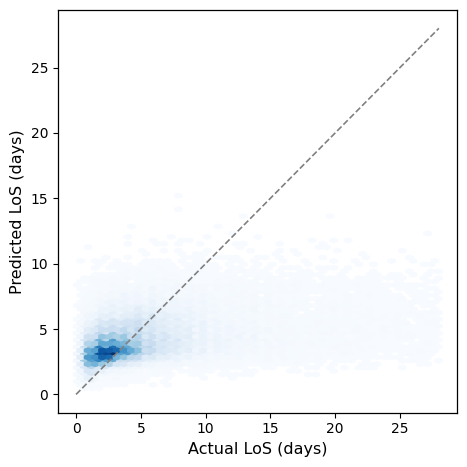

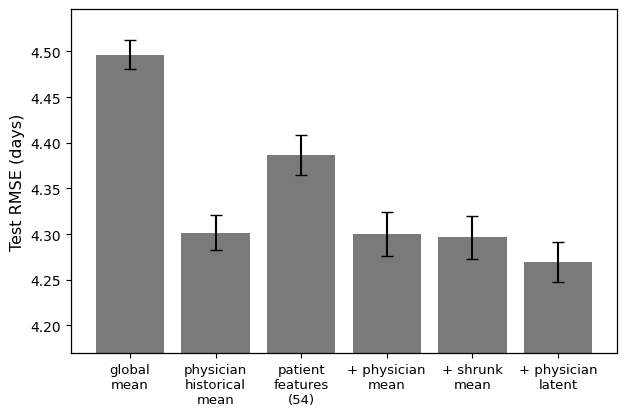

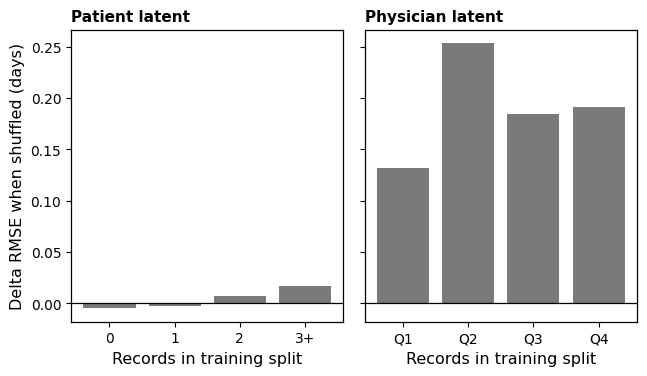

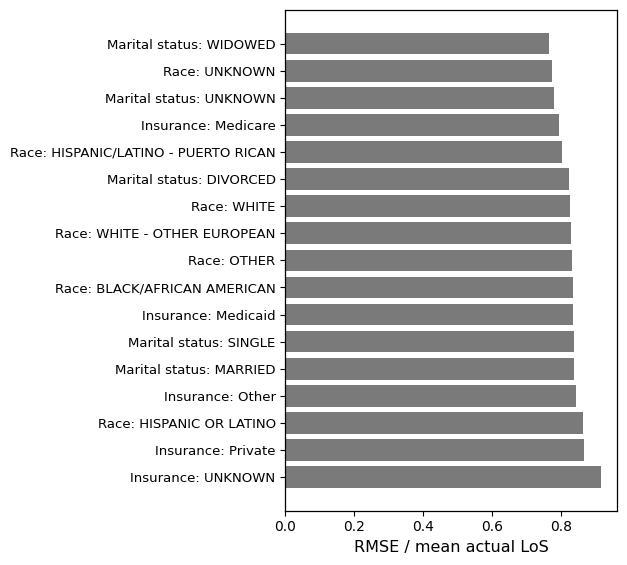

In [17]:
# [그림 전용] 저장된 CSV·배열만 읽는다
# v2 (2026-07-31): 원고 삽입 크기에서 본문 11 pt와 비슷하게 읽히도록 폰트를
# 키우고, 캔버스를 삽입 폭에 맞췄다 — 넓은 그림 3종은 6.4 in, 산점도는 4.8 in.
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11.5,
    "axes.titlesize": 11.5,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.9,
})

main = pd.read_csv(MAIN_CSV)
agg = main.groupby("variant")["rmse_days"].agg(["mean", "std"])

print("[Figure] Length of stay: predicted vs actual (days), representative fold")
t_days = np.load(ART_DIR / "p_test_true_days.npy")
p_days = np.load(ART_DIR / "p_test_pred_days.npy")
fig, ax = plt.subplots(figsize=(4.8, 4.8))       # 원고 삽입 폭 4.8 in
ax.hexbin(t_days, p_days, gridsize=50, mincnt=1, cmap="Blues")
ax.plot([0, LOS_MAX_D], [0, LOS_MAX_D], "--", color="gray", lw=1.2)
ax.set_xlabel("Actual LoS (days)"); ax.set_ylabel("Predicted LoS (days)")
fig.tight_layout(); save_fig(fig, "fig_pred_vs_actual"); plt.show()

print("[Figure] Test RMSE by what physician information is encoded")
ORDER = ["mean", "phy_mean", "pf", "pf+phy_mean", "pf+phy_mean_shrunk", "pf+PhyLat"]
# 두 줄 라벨은 6.4 in 폭에서 서로 겹친다("historical mean" x "features (54)").
# 긴 것만 세 줄로 쪼갠다.
LAB = ["global\nmean", "physician\nhistorical\nmean", "patient\nfeatures\n(54)",
       "+ physician\nmean", "+ shrunk\nmean", "+ physician\nlatent"]
sel = [v for v in ORDER if v in agg.index]
fig, ax = plt.subplots(figsize=(6.4, 4.3))
ax.bar(range(len(sel)), agg.loc[sel, "mean"],
       yerr=agg.loc[sel, "std"], capsize=4, color="#7a7a7a")
ax.set_xticks(range(len(sel)))
ax.set_xticklabels([LAB[ORDER.index(v)] for v in sel], fontsize=9.5)
ax.set_ylabel("Test RMSE (days)")
lo = float(agg.loc[sel, "mean"].min()); hi = float(agg.loc[sel, "mean"].max())
ax.set_ylim(lo - 0.10, hi + 0.05)
fig.tight_layout(); save_fig(fig, "fig_encoding_physician"); plt.show()

print("[Figure] Shuffle importance by number of training records per entity")
st = pd.read_csv(TABLE_DIR / "p_stratified.csv")
fig, ax = plt.subplots(1, 2, figsize=(6.6, 3.9), sharey=True)
for a, (nm, ttl) in zip(ax, [("patient", "Patient latent"),
                             ("physician", "Physician latent")]):
    s = st[st.latent == nm]
    a.bar(s["stratum"].astype(str), s["delta"], color="#7a7a7a")
    a.axhline(0, color="k", lw=0.9)
    a.set_xlabel("Records in training split")
    # 축 안에 두면 Q2 막대와 겹친다. 축 바깥 위로 올린다.
    a.text(0.0, 1.02, ttl, transform=a.transAxes, va="bottom", ha="left",
           fontsize=11, weight="bold")
ax[0].set_ylabel("Delta RMSE when shuffled (days)")
fig.tight_layout(); save_fig(fig, "fig_records_vs_contribution"); plt.show()

print("[Figure] Relative error by demographic group (fold 0 held-out)")
fair = pd.read_csv(TABLE_DIR / "p_fairness.csv").sort_values("relative_rmse")
# 속성명은 표 6과 같은 표기로. n은 표 6에 있으므로 라벨에서 뺀다 — 넣으면
# 라벨이 그림 폭의 절반을 먹어 막대를 읽을 수 없다.
ATTR = {"insurance": "Insurance", "race": "Race",
        "marital_status": "Marital status"}
fig, ax = plt.subplots(figsize=(6.4, max(3.4, 0.34 * len(fair))))
ax.barh(range(len(fair)), fair["relative_rmse"], color="#7a7a7a")
ax.set_yticks(range(len(fair)))
ax.set_yticklabels([f"{ATTR.get(r.attribute, r.attribute)}: {r.group}"
                    for r in fair.itertuples()], fontsize=9.5)
ax.invert_yaxis(); ax.set_xlabel("RMSE / mean actual LoS")
fig.tight_layout(); save_fig(fig, "fig_fairness"); plt.show()

print("\n저장된 그림: fig_pred_vs_actual / fig_encoding_physician / "
      "fig_records_vs_contribution / fig_fairness (각 PNG+PDF, 300dpi)")